✅ GPU Enabled
🚀 Loading Data...
📊 Class Distribution: Counter({'Abrasion': 77, 'Hole': 49, 'Color': 38})

🔥 Fold 1
2/2 [==============================] - 0s 52ms/step

🔥 Fold 2
2/2 [==============================] - 0s 44ms/step

🔥 Fold 3
2/2 [==============================] - 0s 43ms/step

🔥 Fold 4
2/2 [==============================] - 0s 43ms/step

🔥 Fold 5
1/1 [==============================] - 0s 25ms/step

📊 Classification Report:
              precision    recall  f1-score   support

    Abrasion       0.75      0.88      0.81        77
       Color       0.71      0.45      0.55        38
        Hole       0.92      0.92      0.92        49

    accuracy                           0.79       164
   macro avg       0.79      0.75      0.76       164
weighted avg       0.79      0.79      0.78       164



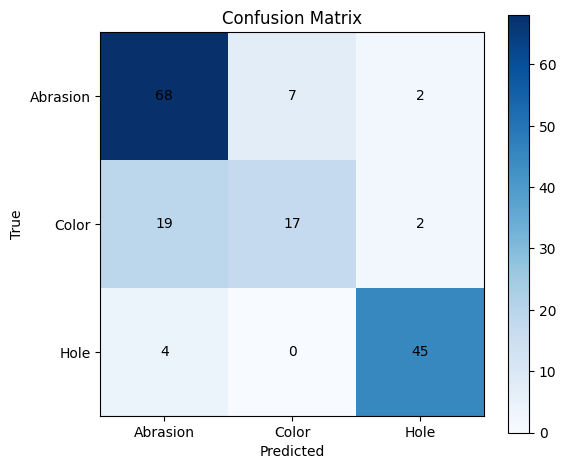

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from collections import Counter
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier

# ================= GPU =================
tf.keras.backend.clear_session()
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
print("✅ GPU Enabled")

# ================= PARAM =================
DATA_PATH = "./IndustrialDataSet/"
IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS1 = 20
EPOCHS2 = 10
N_SPLITS = 5

# ================= LOAD DATA =================
def read_data(path):
    X, y = [], []
    for folder in os.listdir(path):
        p = os.path.join(path, folder)
        if not os.path.isdir(p): continue
        for img_name in os.listdir(p):
            if "_mask" in img_name: continue
            img = cv2.imread(os.path.join(p, img_name))
            if img is not None:
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                X.append(img / 255.0)
                y.append(folder)
    return np.array(X), np.array(y)

print("🚀 Loading Data...")
X, y = read_data(DATA_PATH)
print("📊 Class Distribution:", Counter(y))

# ================= ENCODE =================
encoder = OneHotEncoder(sparse_output=False)
y_one = encoder.fit_transform(y.reshape(-1,1))
y_labels = np.argmax(y_one, axis=1)

# ================= CLASS WEIGHT =================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_labels),
    y=y_labels
)
class_weights = dict(enumerate(class_weights))

# ================= AUG =================
train_gen = ImageDataGenerator(
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

# ================= KFOLD =================
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

all_true = []
all_pred = []

for fold,(tr,va) in enumerate(kf.split(X,y_labels),1):
    print(f"\n🔥 Fold {fold}")

    X_tr, X_va = X[tr], X[va]
    y_tr, y_va = y_one[tr], y_one[va]

    # ================= MODEL =================
    base = EfficientNetB0(weights='imagenet', include_top=False,
                          input_shape=(IMG_SIZE,IMG_SIZE,3))

    for l in base.layers:
        l.trainable = False

    inp = layers.Input((IMG_SIZE,IMG_SIZE,3))
    x = base(inp)
    x = layers.GlobalAveragePooling2D(name="feat")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(len(encoder.categories_[0]), activation='softmax')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # ================= STAGE 1 =================
    model.fit(train_gen.flow(X_tr, y_tr, batch_size=BATCH_SIZE),
              epochs=EPOCHS1,
              class_weight=class_weights,
              verbose=0)

    # ================= FINE-TUNE =================
    for l in base.layers[-20:]:
        l.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(train_gen.flow(X_tr, y_tr, batch_size=BATCH_SIZE),
              epochs=EPOCHS2,
              class_weight=class_weights,
              verbose=0)

    # ================= FEATURE =================
    feat_model = Model(model.input, model.get_layer("feat").output)

    tr_feat = feat_model.predict(X_tr)
    va_feat = feat_model.predict(X_va)

    # ================= XGBOOST =================
    xgb = XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8
    )

    xgb.fit(tr_feat, np.argmax(y_tr, axis=1))

    preds = xgb.predict(va_feat)

    all_true.extend(np.argmax(y_va, axis=1))
    all_pred.extend(preds)

# ================= FINAL REPORT =================
print("\n📊 Classification Report:")
print(classification_report(all_true, all_pred, target_names=encoder.categories_[0]))

# ================= CONFUSION MATRIX =================
cm = confusion_matrix(all_true, all_pred)
labels = encoder.categories_[0]

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()